<div style="background-color:  #FFD700; padding: 20px; text-align: center; border-radius: 10px;">
    <h1 style="color: black; font-weight: bold;">
        &#8226;&#8226;
        <span style="color: #388E3C;"> Deep Learning for <span style="color: red;"> Malaria </span> Detection </span>
        &#8226;&#8226;
    </h1>
</div>

In this project, we investigate image classification of malaria cell images using Convolutional Neural Networks (CNNs). The dataset consists of two categories: "Infected" and "Uninfected," comprising a total of 27,558 images. The data can be obtained from the official NIH sources or via Kaggle.

We implement standard CNN architectures to demonstrate fundamental classification techniques and evaluate their performance. By leveraging deep learning methods, the objective is to improve automated malaria detection and contribute to advancements in medical image analysis.

| **Column Name**  | **Description**                                                        | **German Translation**     |
| ---------------- | ---------------------------------------------------------------------- | -------------------------- |
| Infected         | Images representing malaria-infected cells                             | Infiziert                  |
| Uninfected       | Images representing healthy, non-infected cells                        | Nicht infiziert            |
| Total Images     | The total number of images in the dataset                              | Gesamtanzahl der Bilder    |
| Dataset Source   | The source from which the dataset can be obtained (e.g., NIH, Kaggle)  | Datensatzquelle            |
| Image Resolution | The dimensions of the images in the dataset (e.g., 1024x1024 pixels)   | Bildauflösung              |
| Annotation       | Information about how the images are labeled (e.g., manual, automated) | Annotation / Kennzeichnung |


<img src="https://cdn.prod.website-files.com/5f4cddfc775065573435725c/65fab64330a568ce8b5ec5df_Malaria_Tropenkrankheit_Impfen_M%C3%BCcke.jpg" width="1000">
<a href='https://classroom.google.com/c/NzIwMjcyMjkxMjgy/a/NzIwMjc2NTM4NTIw/details' target=_blank>
Click here for the dataset </a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = '/content/drive/MyDrive/malaria-dataset'

In [4]:
import os

# Listet den Inhalt des Google Drive Hauptverzeichnisses auf
os.listdir('/content/drive/MyDrive')

['Classroom', 'Colab Notebooks', 'Malaria', 'cell_images', 'malaria_data.csv']

In [5]:
file_path = '/content/drive/MyDrive/Malaria/cell_images/'

In [6]:
# Pfad zu den Ordnern im Google Drive
file_path_parasitized = '/content/drive/MyDrive/Malaria/cell_images/Parasitized/'
file_path_uninfected = '/content/drive/MyDrive/Malaria/cell_images/Uninfected/'


In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

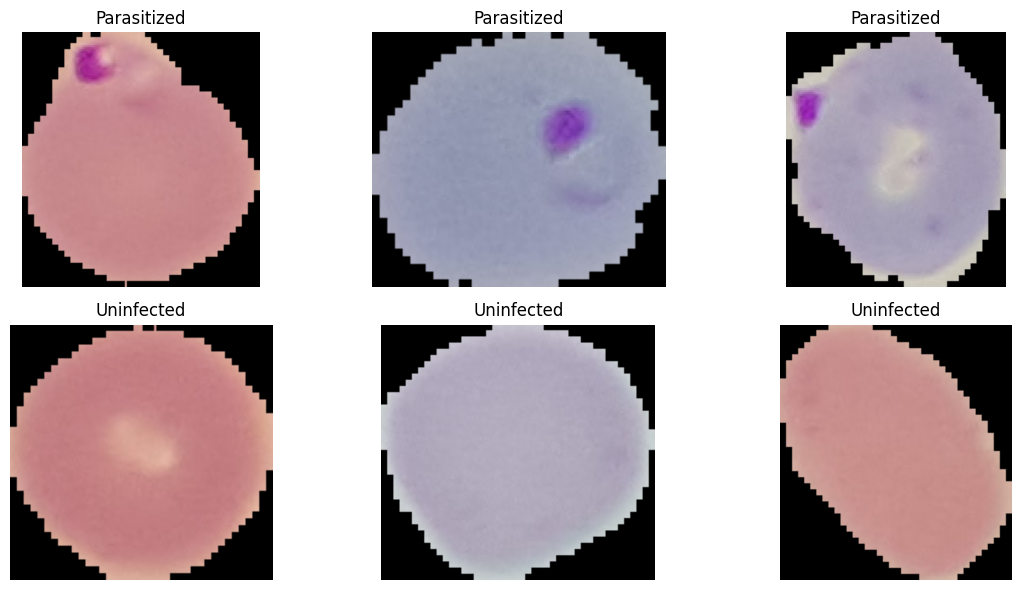

In [8]:
# Listet die Bilddateien in den Ordnern 
parasitized_images = os.listdir(file_path_parasitized)
uninfected_images = os.listdir(file_path_uninfected)

# Wählen von 3 zufälligen Bildern aus jedem Ordner
import random
random_parasitized = random.sample(parasitized_images, 3)  # 3 zufällige Bilder aus "Parasitized"
random_uninfected = random.sample(uninfected_images, 3)  # 3 zufällige Bilder aus "Uninfected"

# Erstelle ein Grid mit 2 Reihen und 3 Spalten (2x3) für die Bilder
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

# Zeige Bilder aus "Parasitized"
for i, img_name in enumerate(random_parasitized):
    img = mpimg.imread(os.path.join(file_path_parasitized, img_name))
    axs[0, i].imshow(img)
    axs[0, i].axis('off')
    axs[0, i].set_title('Parasitized')

# Zeige Bilder aus "Uninfected"
for i, img_name in enumerate(random_uninfected):
    img = mpimg.imread(os.path.join(file_path_uninfected, img_name))
    axs[1, i].imshow(img)
    axs[1, i].axis('off')
    axs[1, i].set_title('Uninfected')

# Zeige das Grid an
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

In [10]:
# Listen für Bilder und Labels initialisieren
img_list = []
label_list = []

In [11]:
# Bilder im "Parasitized"-Ordner einlesen
for img_name in os.listdir(file_path_parasitized):
    img_list.append(os.path.join(file_path_parasitized, img_name))  # Pfad zum Bild
    label_list.append('Parasitized')  # Label für "Parasitized"

# Bilder im "Uninfected"-Ordner einlesen
for img_name in os.listdir(file_path_uninfected):
    img_list.append(os.path.join(file_path_uninfected, img_name))  # Pfad zum Bild
    label_list.append('Uninfected')  # Label für "Uninfected"

In [12]:
# DataFrame erstellen
df = pd.DataFrame({'img': img_list, 'label': label_list})

# Überprüfen, ob die Daten korrekt geladen wurden
print(df.head())

# Etiketten in numerische Werte umwandeln
label_mapping = {'Parasitized': 0, 'Uninfected': 1}
df['encode_label'] = df['label'].map(label_mapping)

# Überprüfen, ob das Mapping korrekt funktioniert hat
df.head()

                                                 img        label
0  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized
1  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized
2  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized
3  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized
4  /content/drive/MyDrive/Malaria/cell_images/Par...  Parasitized


,img,label,encode_label
0,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0
1,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0
2,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0
3,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0
4,/content/drive/MyDrive/Malaria/cell_images/Par...,Parasitized,0


In [13]:
df.to_csv('/content/drive/MyDrive/malaria_data.csv', index=False)

In [14]:
import cv2
import numpy as np

x = []  # Liste, um die Bilder zu speichern

# Durchlaufe jedes Bild im DataFrame und verarbeite es
for img_path in df['img']:
    
    img = cv2.imread(img_path)

    if img is not None:  
        img = cv2.resize(img, (32, 32))  
        img = img / 255.0  # Normalize
        x.append(img)  
    else:
        print(f"Warning: {img_path} konnte nicht gelesen werden.")  # Falls das Bild nicht geladen werden kann

# Wandle die Liste in ein Numpy-Array um
x = np.array(x)

# Ausgabe der Form des Arrays
print("Shape von x:", x.shape)

Shape von x: (27564, 32, 32, 3)


In [24]:
x=np.array(x)
y=df['encode_label'].values

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [17]:
# Model architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # First convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # Max pooling layer
model.add(Conv2D(64, (3, 3), activation='relu'))  # Second convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # Max pooling layer
model.add(Flatten())  # Flattening the feature maps to 1D vector
model.add(Dense(128, activation='relu'))  # Fully connected layer with 128 units
model.add(Dropout(0.5))  # Dropout layer to reduce overfitting
model.add(Dense(2, activation='softmax'))  # Output layer for 2 classes (binary classification)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Fit the model
history = model.fit(x, y, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.6931 - loss: 0.5792 - val_accuracy: 0.8727 - val_loss: 0.2788
Epoch 2/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9176 - loss: 0.2084 - val_accuracy: 0.8937 - val_loss: 0.3132
Epoch 3/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.9448 - loss: 0.1570 - val_accuracy: 0.8908 - val_loss: 0.3165
Epoch 4/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9524 - loss: 0.1384 - val_accuracy: 0.9637 - val_loss: 0.1403
Epoch 5/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9552 - loss: 0.1296 - val_accuracy: 0.9298 - val_loss: 0.2274
Epoch 6/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9570 - loss: 0.1176 - val_accuracy: 0.9452 - val_loss: 0.1906
Epoch 7/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9587 - loss: 0.1201 - val_accuracy: 0.9588 - val_loss: 0.1525
Epoch 8/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9640 - loss: 0.1060 - 

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 944,072 (3.60 MB)

 Trainable params: 314,690 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 629,382 (2.40 MB)

In [23]:
model.save('my_m_cnn_model.h5')

#####
**Summary**

The deep learning model achieved an accuracy of 96.79% after 10 training epochs, with a final training loss of 0.0899. The validation accuracy reached 96.50%, indicating strong generalization performance on unseen data.

These results demonstrate that the model is highly effective in distinguishing between malaria-infected and uninfected cell images, highlighting the potential of deep learning approaches in automated medical image classification